In [1]:
from utils import *
from model_utils import *
from visualizations import *
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
import joblib

In [2]:
# datasets splits folder path
datasets_splits_folder_path = "../dataset/splits/v1"

In [3]:
# load label encoder
transformers_path = "./transfomers"
le = joblib.load(f"{transformers_path}/label_encoder.pkl")

In [4]:
X_train, y_train, X_dev, y_dev, X_test, y_test = load_data(datasets_splits_folder_path)

# check the shapes of the datasets
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_dev shape:", X_dev.shape)
print("y_dev shape:", y_dev.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (20540, 42)
y_train shape: (20540,)
X_dev shape: (2567, 42)
y_dev shape: (2567,)
X_test shape: (2568, 42)
y_test shape: (2568,)


In [5]:
X_train[:5]

,x1,y1,x2,y2,x3,y3,x4,y4,x5,y5,...,x17,y17,x18,y18,x19,y19,x20,y20,x21,y21
0,159.707960,295.80722,167.253140,289.28845,171.947140,282.90234,173.94840,276.80420,175.16832,271.36984,...,159.45110,251.65263,154.265290,273.57693,154.33780,266.59882,154.39575,262.02438,154.41461,257.88693
1,111.113785,197.83873,115.414010,179.15083,126.650116,161.16145,134.29690,147.69128,134.56212,135.40723,...,152.41246,194.94882,148.141970,200.46864,165.40868,203.30000,175.78496,206.63016,184.82541,208.83627
2,111.572480,201.85477,118.025154,193.73083,118.788826,183.25960,111.06031,175.99445,102.39017,171.67297,...,106.48782,181.95824,99.176216,178.87938,96.92235,175.54149,100.71361,181.33572,103.96564,186.34886
3,134.884030,270.36010,146.096070,266.05374,156.054960,258.92340,163.19798,252.90840,164.89212,244.89627,...,146.16782,201.51768,127.770065,235.02124,126.77072,222.51634,127.75249,214.08505,129.67673,207.31053
4,100.787770,181.61578,118.487840,173.62929,134.799670,155.55620,138.00179,136.42476,130.78911,123.97259,...,104.67175,146.41678,88.961030,137.19592,93.54382,130.30640,96.08535,142.77351,94.42624,145.73808


In [6]:
y_train[:5]

0    12
1     0
2     9
3     6
4     2
Name: label, dtype: int64

In [7]:
# convert to numpy array
X_train_np = X_train.to_numpy()
y_train_np = y_train.to_numpy()

X_dev_np = X_dev.to_numpy()
y_dev_np = y_dev.to_numpy()

X_test_np = X_test.to_numpy()
y_test_np = y_test.to_numpy()

## RandomForestClassifier

In [8]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

In [9]:
rf_clf = train_model(rf_model, X_train_np, y_train_np)

In [10]:
print(f"Random Forest Performance on Train Set:\n")

display_metrics(rf_clf, X_train_np, y_train_np, "Random Forest")

Random Forest Performance on Train Set:

Random Forest accuracy = 1.00
Random Forest precision = 1.00
Random Forest recall = 1.00
Random Forest f1_score = 1.00


In [11]:
print(f"Random Forest Performance on Dev Set:\n")

display_metrics(rf_clf, X_dev_np, y_dev_np, "Random Forest")

Random Forest Performance on Dev Set:

Random Forest accuracy = 0.85
Random Forest precision = 0.85
Random Forest recall = 0.85
Random Forest f1_score = 0.85


In [12]:
rf_metrics_dev = evaluate_model(rf_clf, X_dev_np, y_dev_np)

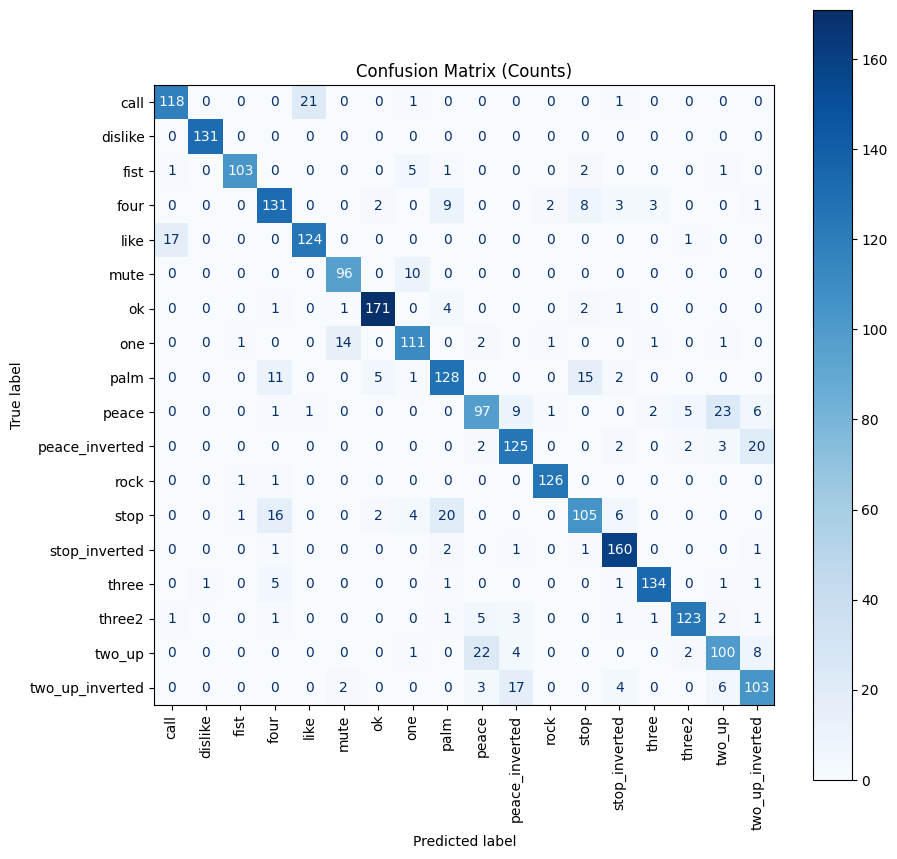

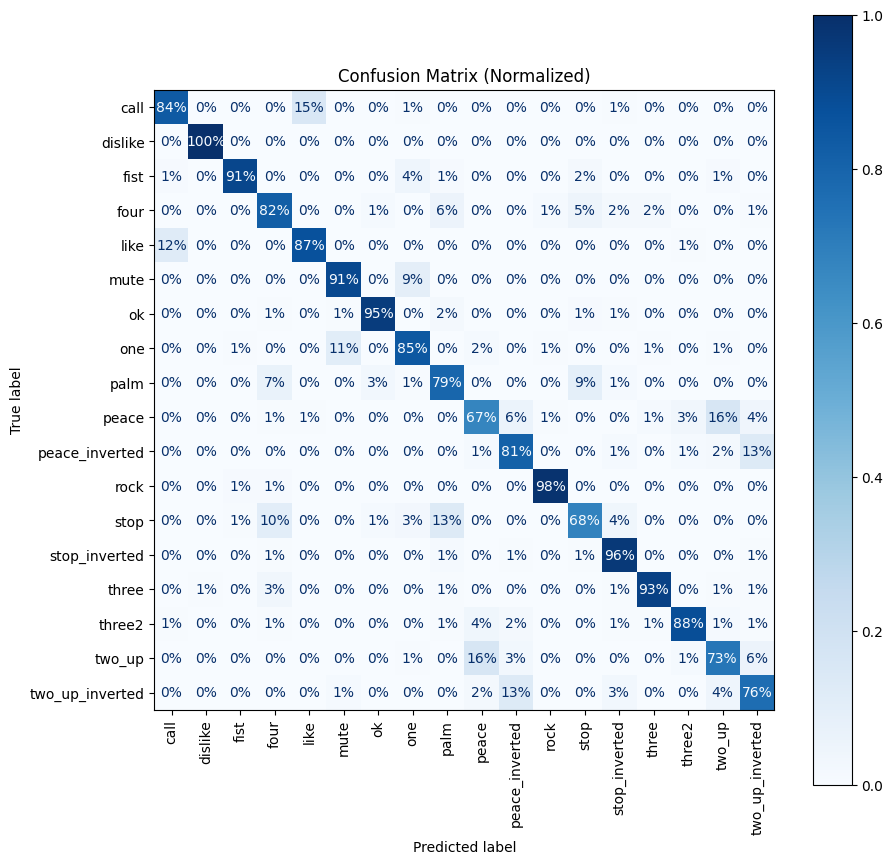

In [ ]:
# plot confusion matrix for dev set
rf_cm = rf_metrics_dev["confusion_matrix"]

plot_confusion_matrix(rf_cm, le, model_name="Random Forest")

d:\ITI Materials\Projects\Hand Marks Detection\Hands_Marks_Detection_main\hand_gest_env\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


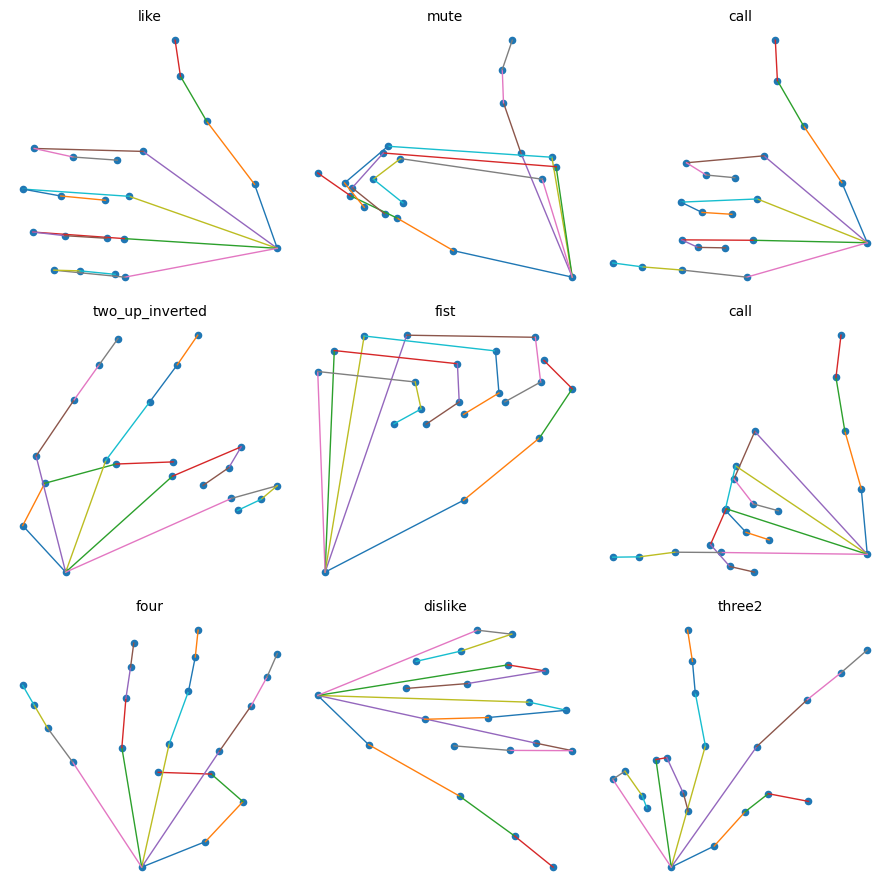

In [14]:
plot_correct_landmarks(
    rf_clf,
    X_dev,
    y_dev_np,
    le,
    n_samples=9
)

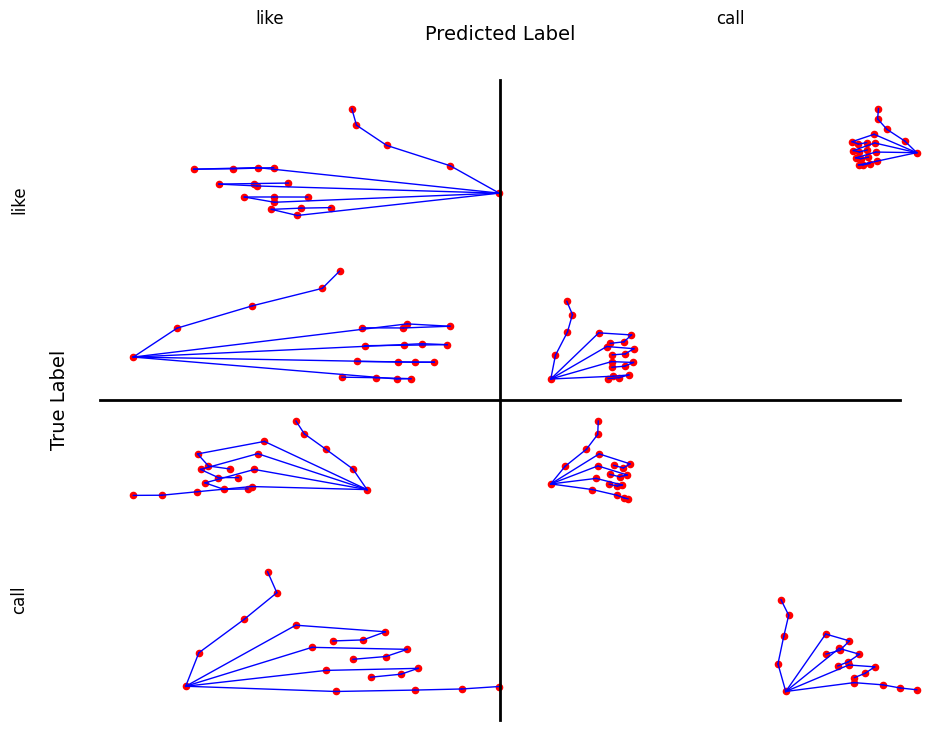

In [15]:
plot_two_class_table(rf_clf, X_dev_np, y_dev_np, le, "like", "call", n_per_cell=2)

## SVM

In [16]:
svm_model = SVC(kernel='rbf', C=1, gamma='scale')

In [17]:
svm_clf = train_model(svm_model, X_train_np, y_train_np)

In [18]:
print(f"SVM Performance on Train Set:\n")

display_metrics(svm_clf, X_train_np, y_train_np, "SVM")

SVM Performance on Train Set:

SVM accuracy = 0.83
SVM precision = 0.84
SVM recall = 0.83
SVM f1_score = 0.83


In [19]:
print(f"SVM Performance on Sev Set:\n")

display_metrics(svm_clf, X_dev_np, y_dev_np, "SVM")

SVM Performance on Sev Set:

SVM accuracy = 0.81
SVM precision = 0.82
SVM recall = 0.81
SVM f1_score = 0.81


In [20]:
svm_metrics_dev = evaluate_model(svm_clf, X_dev_np, y_dev_np)

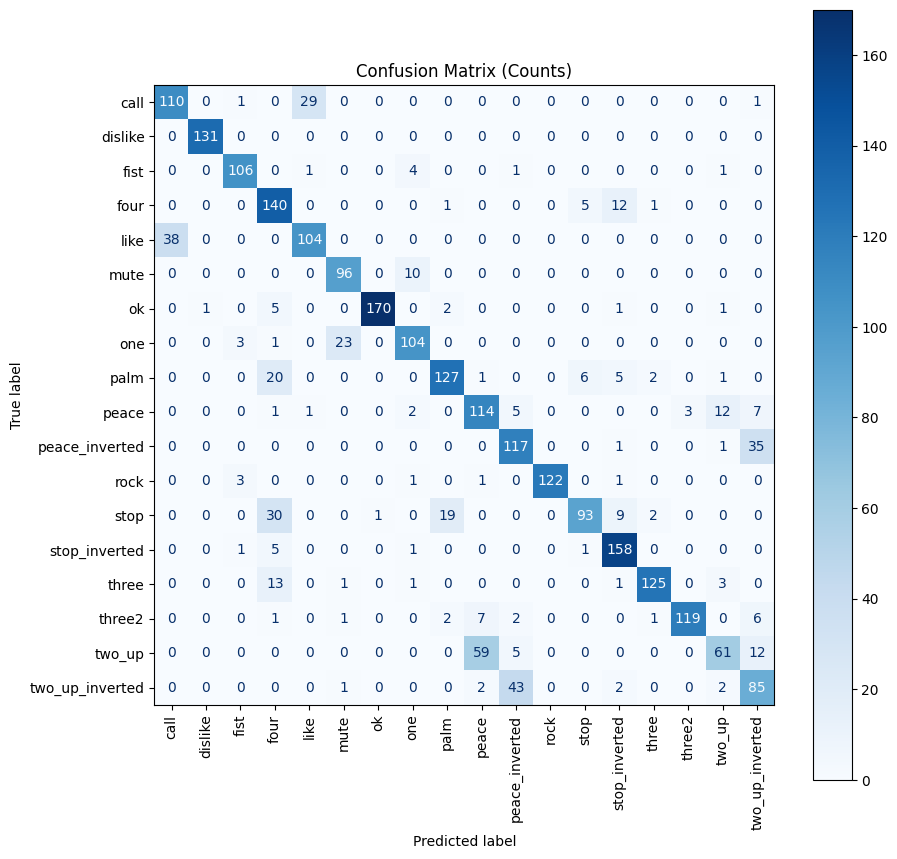

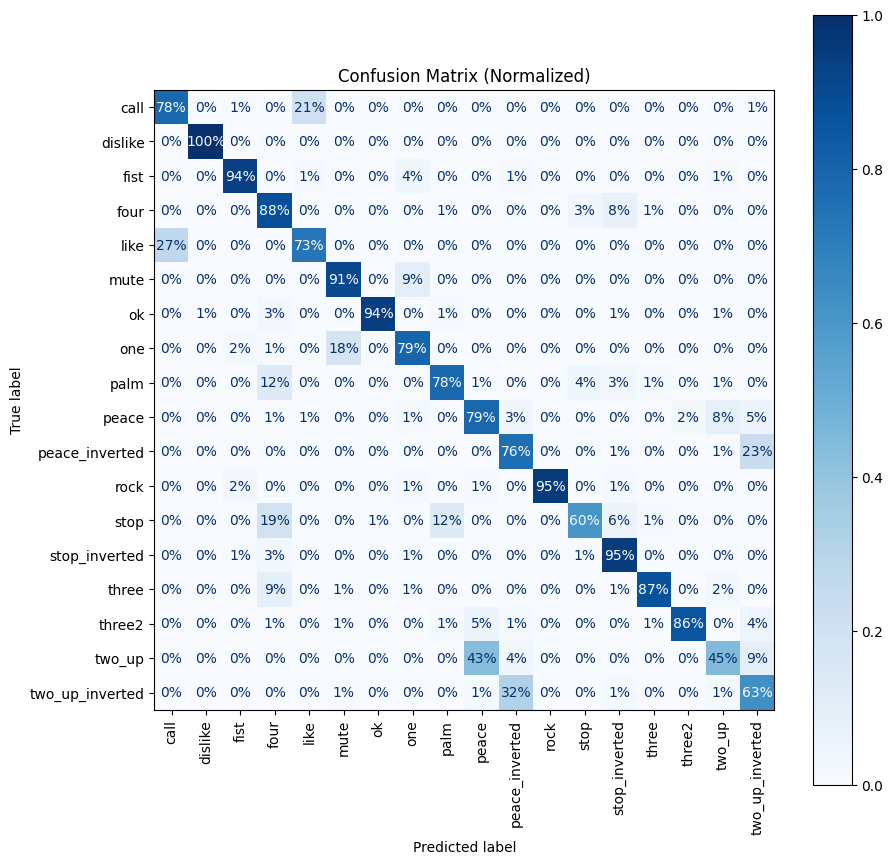

In [ ]:
# plot confusion matrix for dev set
svm_cm = svm_metrics_dev["confusion_matrix"]

plot_confusion_matrix(svm_cm, le, model_name="SVM")

d:\ITI Materials\Projects\Hand Marks Detection\Hands_Marks_Detection_main\hand_gest_env\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(


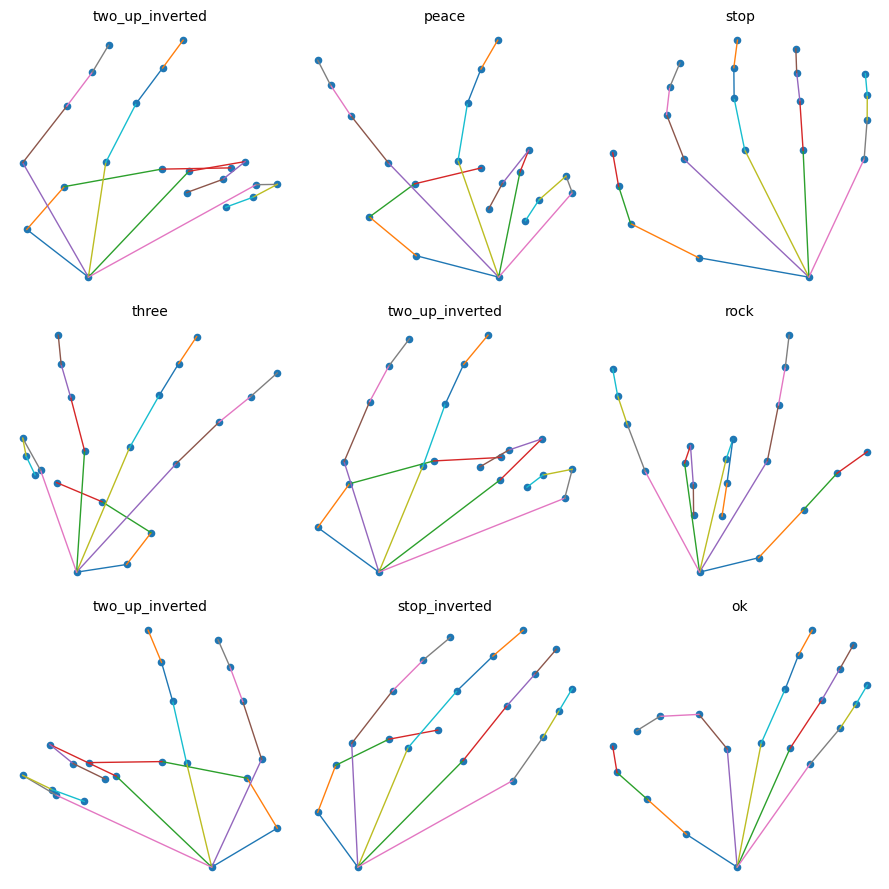

In [22]:
plot_correct_landmarks(
    svm_clf,
    X_dev,
    y_dev,
    le,
    n_samples=9
)

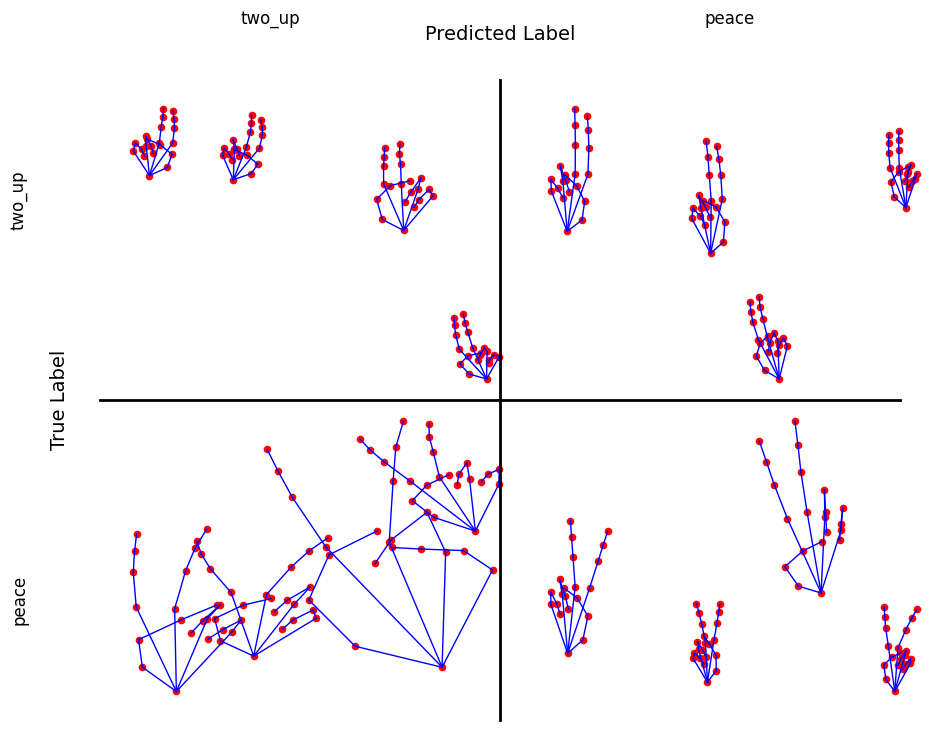

In [23]:
plot_two_class_table(svm_clf, X_dev_np, y_dev_np, le, "two_up", "peace", n_per_cell=4)

## DecisionTreeClassifier

In [24]:
dt_model = DecisionTreeClassifier(random_state=0) 

In [25]:
dt_clf = train_model(dt_model, X_train_np, y_train_np)

In [26]:
dt_metrics_dev = evaluate_model(dt_clf, X_dev_np, y_dev_np)

In [27]:
print(f"Decision Tree Performance on Train Set:\n")

display_metrics(dt_clf, X_train_np, y_train_np, "Decision Tree")

Decision Tree Performance on Train Set:

Decision Tree accuracy = 1.00
Decision Tree precision = 1.00
Decision Tree recall = 1.00
Decision Tree f1_score = 1.00


In [28]:
print(f"Decision Tree Performance on Dev Set:\n")

display_metrics(dt_clf, X_dev_np, y_dev_np, "Decision Tree")

Decision Tree Performance on Dev Set:

Decision Tree accuracy = 0.71
Decision Tree precision = 0.72
Decision Tree recall = 0.72
Decision Tree f1_score = 0.72


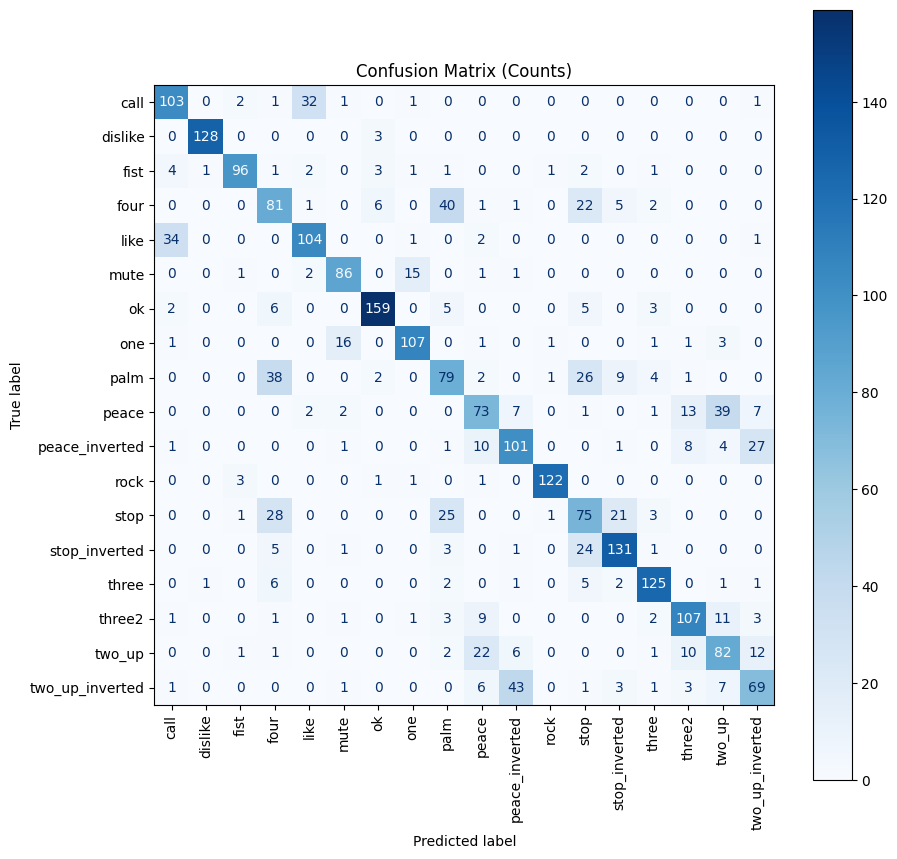

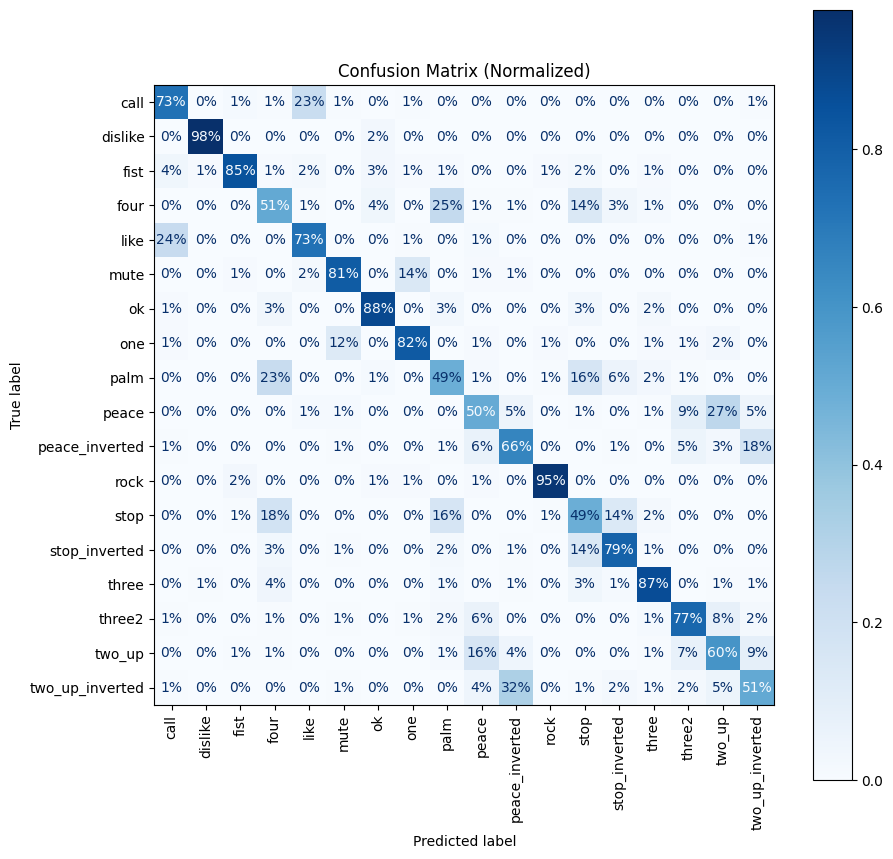

In [ ]:
# plot confusion matrix for dev set
dt_cm = dt_metrics_dev["confusion_matrix"]

plot_confusion_matrix(dt_cm, le, model_name="Decision Tree")

d:\ITI Materials\Projects\Hand Marks Detection\Hands_Marks_Detection_main\hand_gest_env\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(


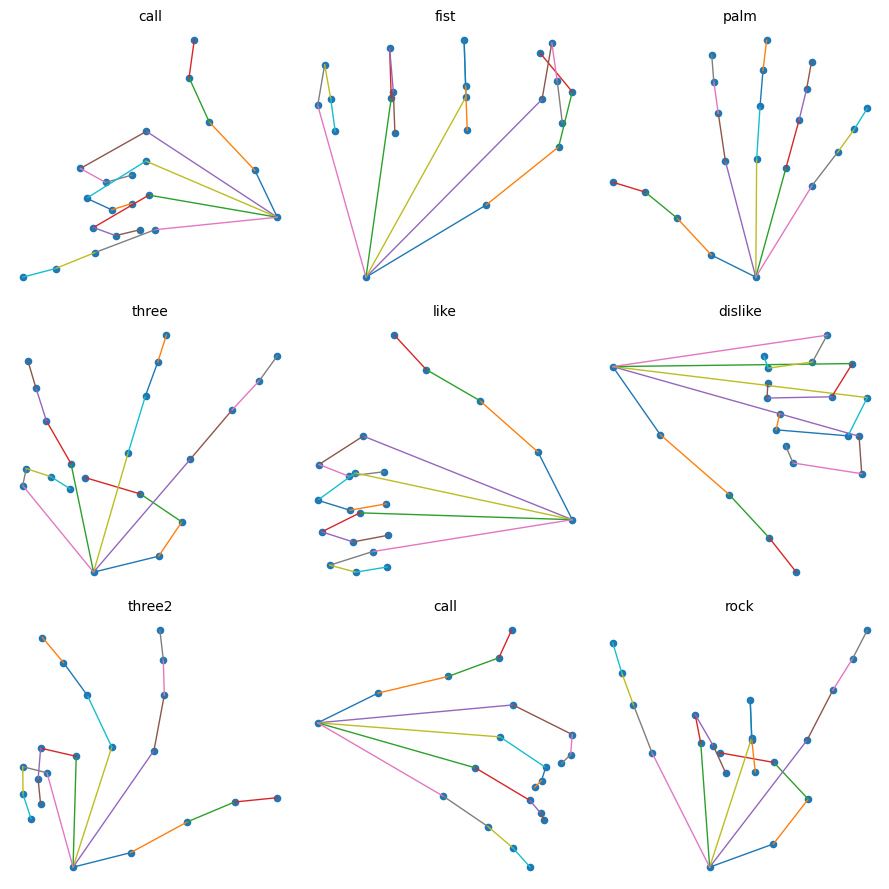

In [30]:
plot_correct_landmarks(
    dt_clf,
    X_dev,
    y_dev_np,
    le,
    n_samples=9
)

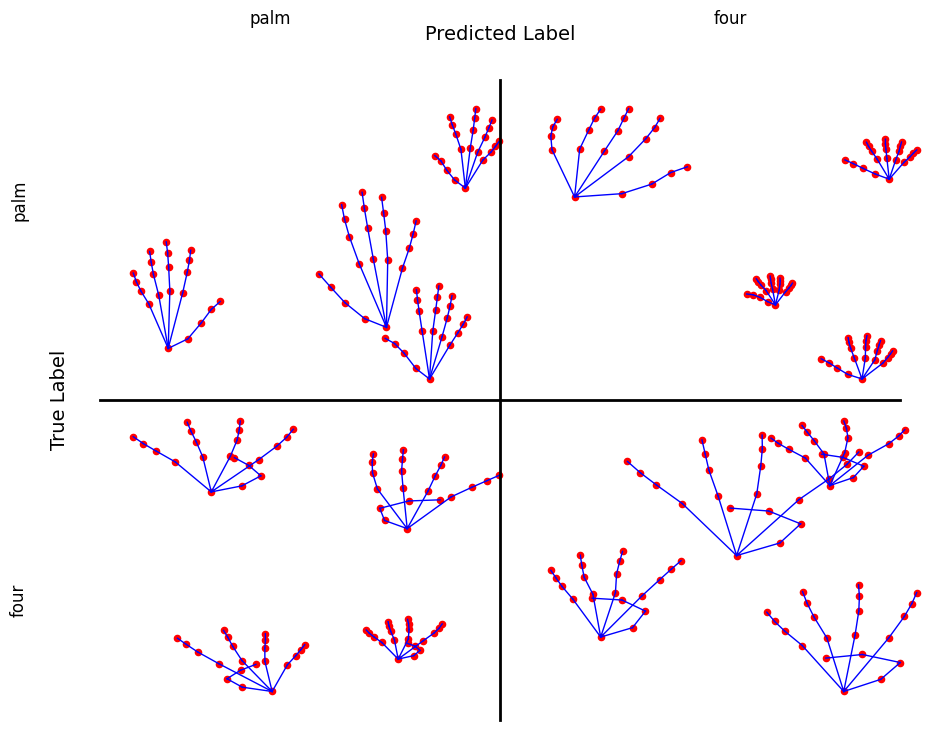

In [31]:
plot_two_class_table(dt_clf, X_dev_np, y_dev_np, le, "palm", "four", n_per_cell=4)

## K-Fold GridSearch 

In [32]:
# model parameters declaration
model_params = {
    "Random Forest": {
        "model": RandomForestClassifier(random_state=42),
        "params":{
            "n_estimators": [50, 80, 90, 100, 120],
            "max_depth": [None, 5, 10, 20],
            "min_samples_split": [2, 5, 10]
        }
    },

    "SVM": {
        "model": SVC(probability=True, random_state=42),
        "params": {
            "C": [0.1, 1, 5, 10],
            "kernel": ["linear", "rbf"]
        }
    },

    "Decision Tree": {
        "model": DecisionTreeClassifier(random_state=42),
        "params": {
            "criterion": ["gini", "entropy"],
            "max_depth": [None, 5, 10, 20],
        }
    }
}

In [33]:
grid_results = run_model_selection_pipeline(model_params, 
                                 X_train_np, y_train_np, 
                                 X_dev_np, y_dev_np
                                 )

KeyboardInterrupt: 

In [ ]:
print(grid_results)

<bound method BaseEstimator.get_params of RandomForestClassifier(n_estimators=90, random_state=42)>